# Section 4: Model Performance Optimization --> Chapter 18: Ensemble Methods


---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

!pip install chefboost==0.0.17
!pip install XGBoost==2.0.3
!pip install CatBoost==1.2.5
!pip install LightGBM==4.1.0
!pip install LogitBoost==0.7
!pip install rotation-forest==1.0
!pip install scikit-learn==1.2.2
!pip install pandas==2.0.3
!pip install numpy==1.25.2
!pip install matplotlib==3.7.1
!pip install pydrive2==1.6.3
!pip install sklearn==1.2.2

ERROR: Could not find a version that satisfies the requirement sklearn==1.2.2 (from versions: 0.0, 0.0.post1, 0.0.post2, 0.0.post4, 0.0.post5, 0.0.post7, 0.0.post9, 0.0.post10, 0.0.post11, 0.0.post12)
ERROR: No matching distribution found for sklearn==1.2.2


---

☑ **Import libraries**

---

In [ ]:
# Standard Library Imports
import time
import numpy as np
import pandas as pd

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

from sklearn.ensemble import *
from sklearn.neighbors import *
from sklearn.naive_bayes import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score, max_error, mean_absolute_error, mean_squared_error, median_absolute_error, r2_score, mean_squared_log_error, mean_poisson_deviance, mean_absolute_percentage_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from logitboost import LogitBoost

from sklearn.dummy import DummyClassifier
from sklearn.utils.multiclass import type_of_target

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from chefboost import Chefboost as chef
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from logitboost import LogitBoost
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, confusion_matrix

# To suppress all warnings:
import warnings
warnings.filterwarnings("ignore")

## 5.1 Ensemble for Regression

####################################################################################################

                                      Decision Tree Regressors                                      

####################################################################################################

Training and evaluating: BaggingRegressor - Bagging


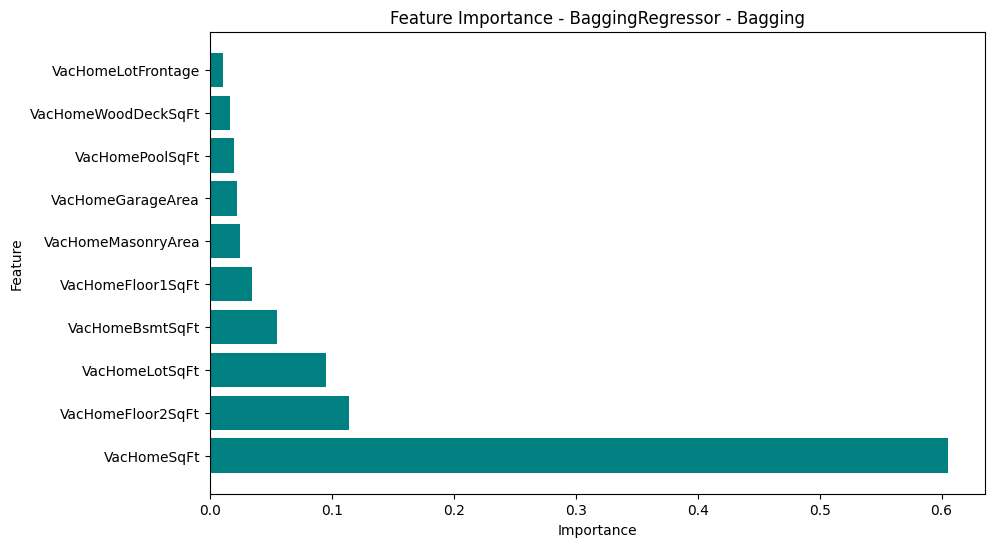

Training and evaluating: BaggingRegressor - Pasting


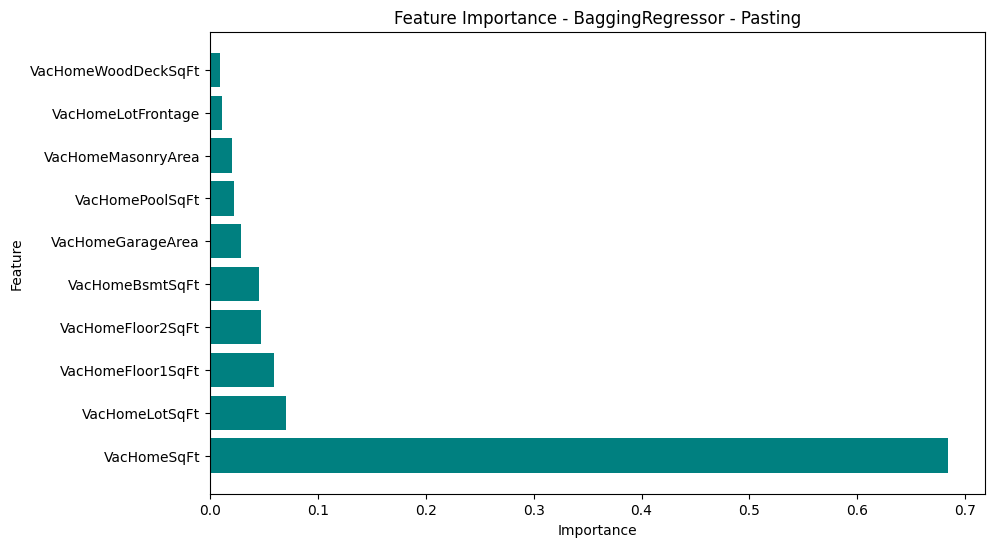

Training and evaluating: GradientBoostingRegressor
Training and evaluating: CatBoostRegressor


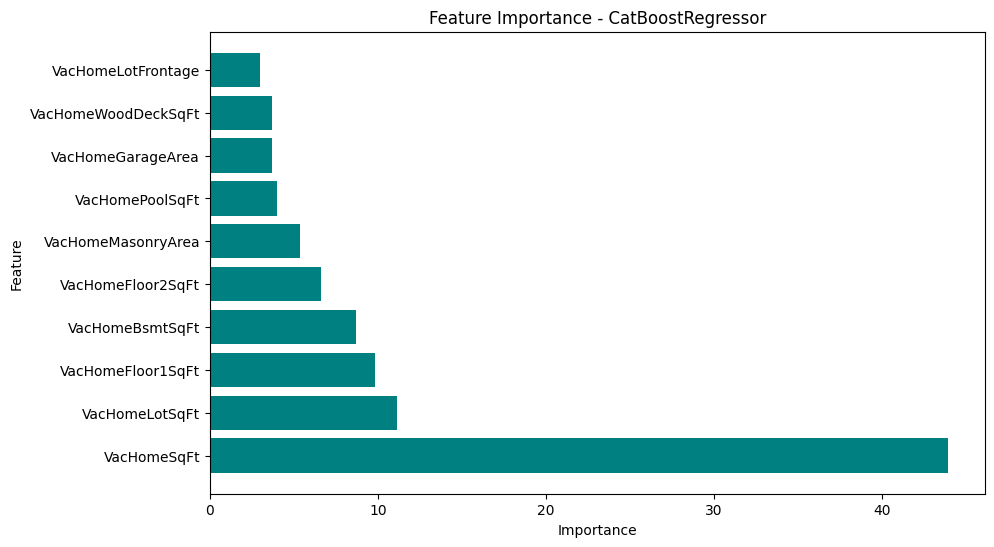

Training and evaluating: LGBMRegressor
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2436
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 10
[LightGBM] [Info] Start training from score 152003.629420
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

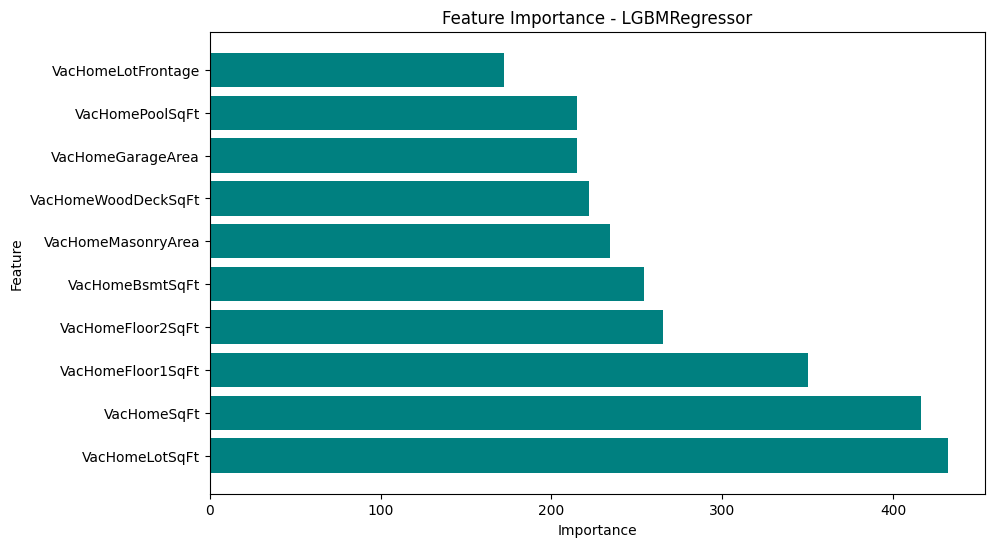

Training and evaluating: XGBRegressor


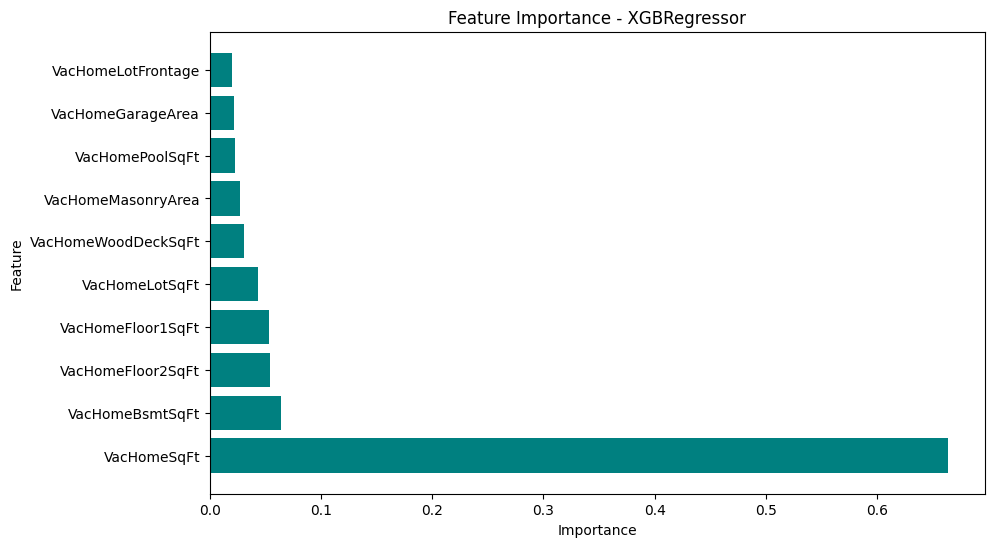

Training and evaluating: HistGradientBoostingRegressor
Training and evaluating: StackingRegressor


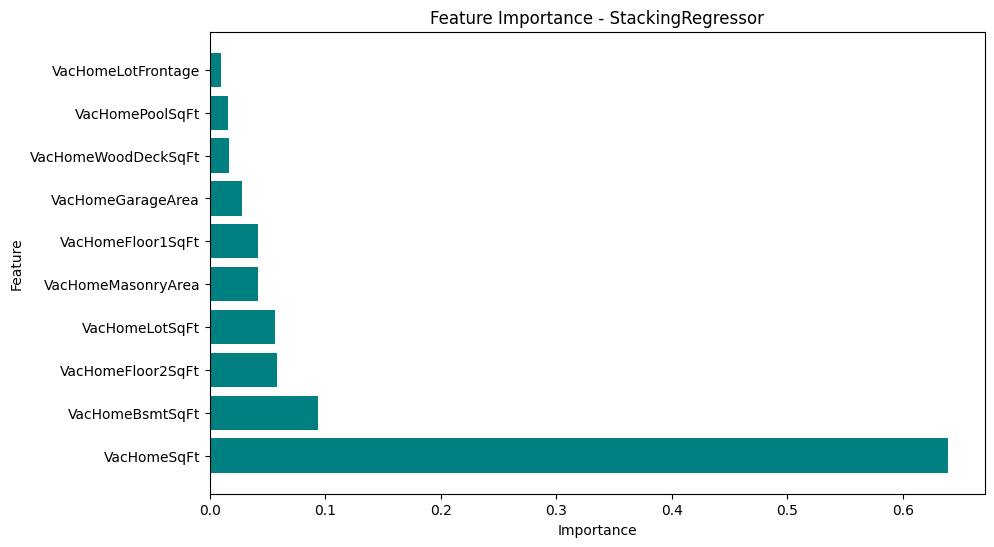

Training and evaluating: ExtraTreesRegressor


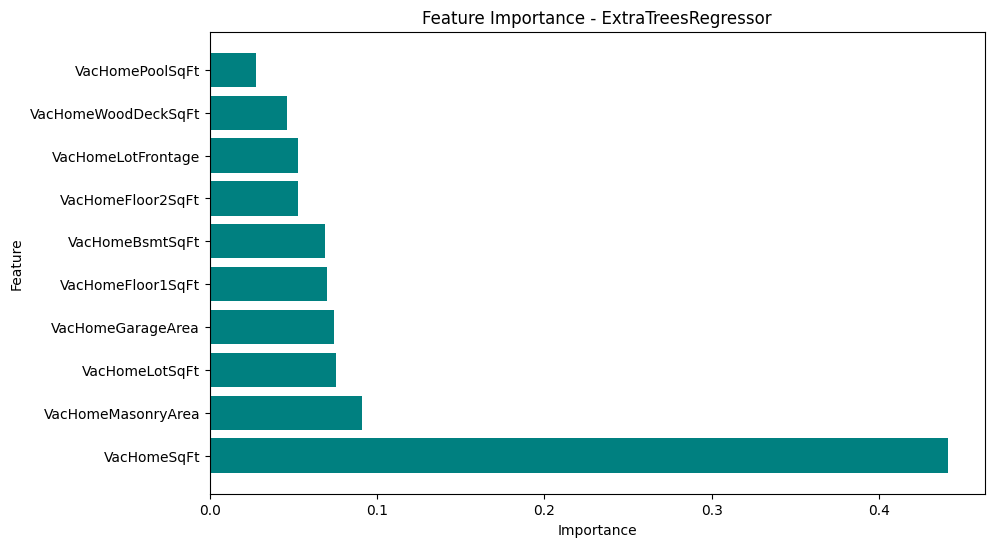

Training and evaluating: RandomForestRegressor


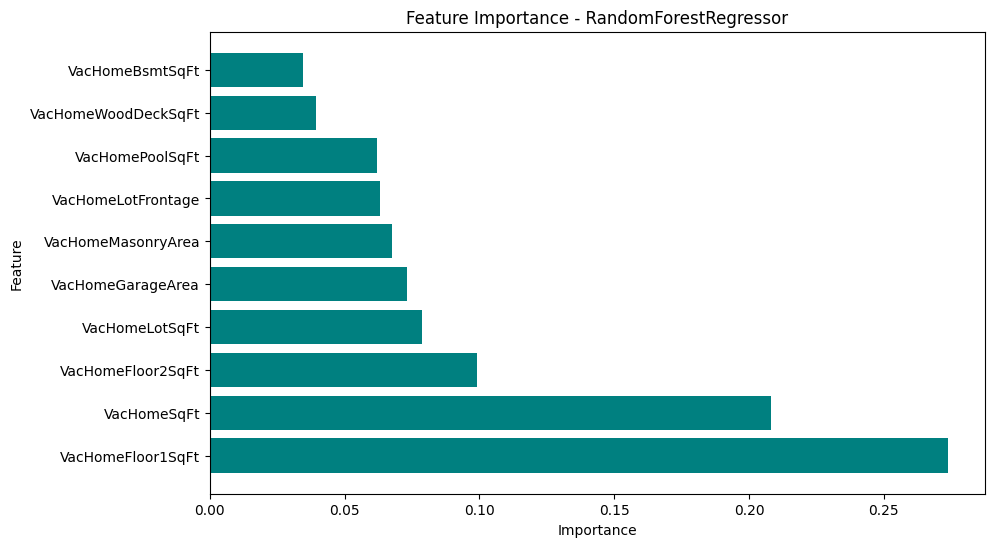

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():

    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():

    target_column = 'VacHomeSalePrice'

    regression_evaluation_columns = ['Data', 'Algorithm', 'Model_Changed', 'Iteration', 'explained_variance',
                                      'max_error', 'neg_mean_absolute_error', 'neg_mean_squared_error',
                                      'neg_root_mean_squared_error', 'neg_mean_squared_log_error',
                                      'neg_median_absolute_error', 'r2', 'neg_mean_poisson_deviance',
                                       'neg_mean_absolute_percentage_error',
                                      'duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt',  'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState','VacHomeInterestInHome'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality','VacHomeReviewDate'
    ]
    return regression_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column

# Function to Split Data
def _3_split_data(df_rawdata, target_column):

    # target_column = 'VacHomeSalePrice'
    if target_column not in df_rawdata.columns:
        raise KeyError(f"Target column '{target_column}' not found in the DataFrame.")

    # Calculate the number of rows needed for the training set (50%)
    training_size = len(df_rawdata) // 2

    # Slice the data to create the training and test sets
    df_train_data = df_rawdata.iloc[:training_size]
    df_test_data = df_rawdata.iloc[training_size:]

    y_split_train = df_train_data[target_column].values
    X_split_train = df_train_data.drop(columns=target_column)
    y_split_test = df_test_data[target_column].values
    X_split_test = df_test_data.drop(columns=target_column)
    return X_split_train, y_split_train, X_split_test, y_split_test


# Functions for Data Processing and Encoding
def _4_preprocess_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    # Impute NaN values
    for col in continuous_columns:
        train_data[col].fillna(train_data[col].mean(), inplace=True)
        test_data[col].fillna(train_data[col].mean(), inplace=True)

    for col in nominal_columns:
        train_data[col].fillna("Unknown", inplace=True)
        test_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        train_data[col].fillna(15, inplace=True)
        test_data[col] = test_data[col].apply(lambda x: 15 if x == 'N' else x)
        test_data[col].fillna(15, inplace=True)

    train_preprocessed_data = train_data.drop(columns=ignore_columns)
    test_preprocessed_data = test_data.drop(columns=ignore_columns)
    return train_preprocessed_data, test_preprocessed_data

# Function to Encode Data
def _5_encode_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    label_encoder = LabelEncoder()
    for col in ordinal_columns:
        train_data[col] = label_encoder.fit_transform(train_data[col].astype(str))
        test_data[col] = label_encoder.transform(test_data[col].astype(str))

    for col in nominal_columns:
        if col in train_data.columns and col in test_data.columns:
            train_data[col] = label_encoder.fit_transform(train_data[col])
            test_data[col] = label_encoder.transform(test_data[col])

    train_encoded_data = pd.get_dummies(train_data, columns=nominal_columns, drop_first=True)
    test_encoded_data = pd.get_dummies(test_data, columns=nominal_columns, drop_first=True)

    return train_encoded_data, test_encoded_data

# Function to PCA
def _7_run_pca(X_train_encoded, X_test_encoded, original_feature_names):

    # Define the number of components you want to keep
    n_components = 10  # You can choose a suitable number

    # Initialize PCA and fit on your data
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_encoded)  # Fit and transform training data
    X_test_pca = pca.fit_transform(X_test_encoded)  # Transform test data using the same PCA model

    # Get the real feature names after PCA
    pca_feature_names = [f"{original_feature_names[j]}" for i, j in zip(range(n_components), pca.components_.argsort()[:, ::-1][:, :n_components].flatten())]

    return X_train_pca, X_test_pca, pca_feature_names

def append_result_df(result_df, data, algo_name, model_change, iteration_number, y_true, y_pred, duration):
    result_row = {
        'Data': data,
        'Algorithm': algo_name,
        'Model_Changed': model_change,
        'Iteration': iteration_number,
        'duration': duration
    }

    # Accuracy Metrics
    result_row['explained_variance'] = explained_variance_score(y_true, y_pred)
    result_row['max_error'] = max_error(y_true, y_pred)

    # Error Metrics
    result_row['neg_mean_absolute_error'] = -mean_absolute_error(y_true, y_pred)
    result_row['neg_mean_squared_error'] = -mean_squared_error(y_true, y_pred)
    result_row['neg_root_mean_squared_error'] = -np.sqrt(mean_squared_error(y_true, y_pred))

    if (y_true >= 0).all() and (y_pred >= 0).all():
        # Only calculate these metrics if all values are non-negative
        result_row['neg_mean_squared_log_error'] = -mean_squared_log_error(y_true, y_pred)
        result_row['neg_median_absolute_error'] = -median_absolute_error(y_true, y_pred)

        # Goodness of Fit
        result_row['r2'] = r2_score(y_true, y_pred)
        result_row['neg_mean_poisson_deviance'] = -mean_poisson_deviance(y_true, y_pred)
        result_row['neg_mean_absolute_percentage_error'] = -mean_absolute_percentage_error(y_true, y_pred)
    else:
        # If any value is negative, set these metrics to NaN or a custom value
        result_row['neg_mean_squared_log_error'] = None
        result_row['neg_median_absolute_error'] = None

        # Goodness of Fit
        result_row['r2'] = None
        result_row['neg_mean_poisson_deviance'] = None
        result_row['neg_mean_absolute_percentage_error'] = None

    result_df = pd.concat([result_df, pd.DataFrame([result_row])], ignore_index=True)
    return result_df

def _9_evaluation_regressors(reg_name, feature_importances, feature_names):
    # Ensure feature names and importances have the same length
    if len(feature_names) != len(feature_importances):
        raise ValueError("Lengths of feature_names and feature_importances must be the same")

    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

    # Sort the DataFrame by importance
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
    plt.title(f'Feature Importance - {reg_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    return

# Function to Train Decision Tree Regressor
def _8_train_regressors(X_train, y_train, X_test, y_test, regression_result_df, feature_names):
    stacking_estimators = [('rf', RandomForestRegressor(n_estimators=2))]

    # Define algorithms
    Regressors ={    ## -- Bagging --
                      'BaggingRegressor - Bagging': BaggingRegressor(base_estimator=None, n_estimators=10, max_samples=1.0,max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
                      , 'BaggingRegressor - Pasting': BaggingRegressor(base_estimator=None, n_estimators=10, max_samples=1.0,max_features=1.0, bootstrap=False, bootstrap_features=False,oob_score=False, warm_start=False, n_jobs=None,random_state=None, verbose=0)
                      # , 'BaggingRegressor - Random Subspaces': BaggingRegressor(base_estimator=None, n_estimators=10,max_samples=1.0, max_features=0.6, bootstrap=True,bootstrap_features=True, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
                      # , 'BaggingRegressor - Random Patches': BaggingRegressor(base_estimator=None, n_estimators=10, max_samples=1.0, max_features=0.6, bootstrap=False,bootstrap_features=True, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

                      ## -- Boosting --
                      # , 'AdaBoostRegressor'                    :  AdaBoostRegressor(base_estimator=None, n_estimators=50, learning_rate=1.0, algorithm='SAMME.R', random_state=None)
                      , 'GradientBoostingRegressor'            :  GradientBoostingRegressor( learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2)
                      , 'CatBoostRegressor'                    :  CatBoostRegressor(silent=True)
                      , 'LGBMRegressor'                        :  LGBMRegressor()
                      # , 'LogitBoost'                           :  LogitBoost(n_estimators=200, random_state=0)
                      , 'XGBRegressor'                         :  XGBRegressor()
                      , 'HistGradientBoostingRegressor'        :  HistGradientBoostingRegressor(learning_rate=0.1, max_iter=100, max_leaf_nodes=31, max_depth=None, min_samples_leaf=20, l2_regularization=0.0, max_bins=255, categorical_features=None, monotonic_cst=None, warm_start=False, early_stopping='auto', scoring='loss', validation_fraction=0.1, n_iter_no_change=10, tol=1e-07, verbose=0, random_state=None)

                      ## -- Stacking --
                      , 'StackingRegressor'                    :  StackingRegressor(stacking_estimators, final_estimator=None, cv=None)
                      # , 'VotingRegressor - Hard'               :  VotingRegressor(estimators=stacking_estimators, voting='hard')
                      # , 'VotingRegressor - Soft'               :  VotingRegressor(estimators=stacking_estimators, voting='soft')

                      ## -- Tree Based Regressors --
                      , 'ExtraTreesRegressor'                  : ExtraTreesRegressor(n_estimators=100, random_state=None,criterion='absolute_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt')
                      , 'RandomForestRegressor'                : RandomForestRegressor(n_estimators=100, criterion='absolute_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt')
                      # , 'RandomTreesEmbedding'               :  RandomTreesEmbedding(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_leaf_nodes=None, min_impurity_decrease=0.0, sparse_output=True)
    }

    # Define variables outside the loop
    tree_depth, node_count, ccp_path = None, None, None

    # Loop through regression algorithms
    for i, (reg_name, reg) in enumerate(Regressors.items()):
        print(f"Training and evaluating: {reg_name}")

        start_time = time.time()

        # Fit the regression algorithm on the training data
        regressor = reg.fit(X_train, y_train)

        # Check if the regressor has a feature_importances_ attribute
        if hasattr(regressor, 'estimators_'):
            # For BaggingRegressor, access the feature importances from the base estimator
            base_estimator = regressor.estimators_[0]  # Assuming the first base estimator
            if hasattr(base_estimator, 'feature_importances_'):
                feature_importances = base_estimator.feature_importances_
            else:
                feature_importances = None
        elif hasattr(regressor, 'feature_importances_'):
            # For other regressors, check if they have feature_importances_
            feature_importances = regressor.feature_importances_
        else:
            feature_importances = None

        # Visualize feature importance if available
        if feature_importances is not None:
            _9_evaluation_regressors(reg_name, feature_importances, feature_names)

        y_pred_train = reg.predict(X_train)
        y_pred_test = reg.predict(X_test)
        # Pause the clock
        end_time = time.time()
        duration = round(end_time - start_time, ndigits=4)

        # Add tree information to the result DataFrame
        regression_result_df = append_result_df(regression_result_df, "Training Set", reg_name, "New Algorithm", 1, y_train, y_pred_train, duration)
        regression_result_df = append_result_df(regression_result_df, "Test Set", reg_name, "New Algorithm", 1, y_test, y_pred_test, duration)

    return regression_result_df

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Training Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    regression_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column = _2_define_variables()
    regression_result_df = pd.DataFrame(columns=regression_evaluation_columns)

    # Split data
    X_split_train, y_split_train, X_split_test, y_split_test = _3_split_data(df_rawdata, target_column)

    train_preprocessed_data, test_preprocessed_data = _4_preprocess_data(X_split_train, X_split_test, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Encode data
    X_train_encoded, X_test_encoded = _5_encode_data(train_preprocessed_data, test_preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 7. Run PCA for dimensionality reduction
    X_train_pca, X_test_pca, pca_feature_names = _7_run_pca(X_train_encoded, X_test_encoded, X_train_encoded.columns)

    # Train and evaluate the model
    regression_result_df = _8_train_regressors(X_train_pca, y_split_train, X_test_pca, y_split_test, regression_result_df, pca_feature_names)

    # Time taken by model
    end_time = time.time()
    duration = round(end_time - start_time, ndigits=4)
    return regression_result_df

if __name__ == "__main__":
    # Print Header
    print_pretty_header("Decision Tree Regressors", "")
    regression_result_df = main()  # Call main() and store the result in regressor_result_df
    regression_result_df  # Now you can access regressor_result_df



In [ ]:
# Print Header
print_pretty_header("Decision Tree Regressors", "Evaluation Metrics")
# Display the DataFrame
regression_result_df.sort_values(by='Data', ascending=False, inplace=True)
regression_result_df

####################################################################################################

                                      Decision Tree Regressors                                      

                                         Evaluation Metrics                                         

####################################################################################################



,Data,Algorithm,Model_Changed,Iteration,explained_variance,max_error,neg_mean_absolute_error,neg_mean_squared_error,neg_root_mean_squared_error,neg_mean_squared_log_error,neg_median_absolute_error,r2,neg_mean_poisson_deviance,neg_mean_absolute_percentage_error,duration
0,Training Set,BaggingRegressor - Bagging,New Algorithm,1,0.943002,1.446273e+05,-9.560675e+03,-2.630011e+08,-1.621731e+04,-8.768481e-03,-5768.500000,0.942978,-1.321629e+03,-6.466340e-02,0.4431
8,Training Set,LGBMRegressor,New Algorithm,1,0.957203,1.884303e+05,-7.103025e+03,-1.973936e+08,-1.404968e+04,-5.963571e-03,-3817.713446,0.957203,-8.877885e+02,-4.774855e-02,1.1894
18,Training Set,RandomForestRegressor,New Algorithm,1,0.958591,1.309880e+05,-8.400048e+03,-1.910674e+08,-1.382271e+04,-7.903771e-03,-5228.601600,0.958574,-9.994087e+02,-5.935734e-02,4.8740
16,Training Set,ExtraTreesRegressor,New Algorithm,1,0.999953,3.427900e+03,-2.341761e+02,-2.187632e+05,-4.677213e+02,-1.816563e-05,-79.680000,0.999953,-1.613200e+00,-1.810764e-03,4.1895
14,Training Set,StackingRegressor,New Algorithm,1,0.885779,1.866669e+05,-1.355848e+04,-5.280165e+08,-2.297861e+04,-1.921488e-02,-6890.186104,0.885519,-2.791734e+03,-9.632076e-02,0.5793
12,Training Set,HistGradientBoostingRegressor,New Algorithm,1,0.954415,1.921767e+05,-7.284479e+03,-2.102511e+08,-1.450004e+04,-6.279255e-03,-3920.827746,0.954415,-9.446480e+02,-4.930462e-02,2.4287
10,Training Set,XGBRegressor,New Algorithm,1,0.999951,2.322227e+03,-3.338831e+02,-2.265043e+05,-4.759247e+02,-1.883353e-05,-230.949219,0.999951,-1.857467e+00,-2.688993e-03,2.4742
6,Training Set,CatBoostRegressor,New Algorithm,1,0.989217,3.439391e+04,-5.374456e+03,-4.973629e+07,-7.052396e+03,-4.096200e-03,-4147.505509,0.989217,-3.962584e+02,-4.355084e-02,8.3246
4,Training Set,GradientBoostingRegressor,New Algorithm,1,0.927969,1.028637e+05,-1.329319e+04,-3.322260e+08,-1.822707e+04,-2.022124e-02,-9952.690342,0.927969,-2.261213e+03,-1.036517e-01,0.5186
2,Training Set,BaggingRegressor - Pasting,New Algorithm,1,1.000000,5.820766e-11,-1.285751e-12,-6.098927e-23,-7.809563e-12,-4.322526e-33,-0.000000,1.000000,-1.993413e-13,-6.003977e-18,0.6205


## 5.2 Ensemble for Classification

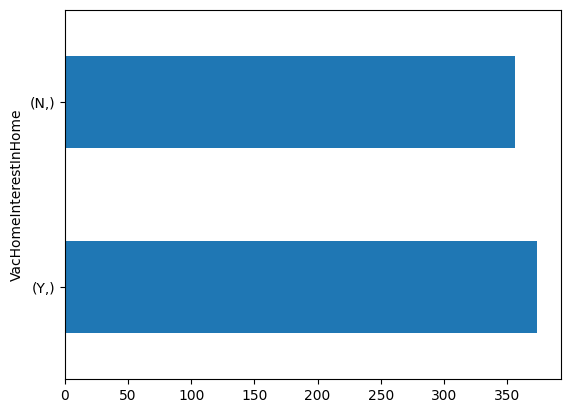

BaggingClassifier - Bagging
BaggingClassifier - Pasting
BaggingClassifier - Random Subspaces
BaggingClassifier - Random Patches
AdaBoostClassifier
GradientBoostingClassifier
CatBoostClassifier
LGBMClassifier
LogitBoost
XGBClassifier
HistGradientBoostingClassifier
StackingClassifier
VotingClassifier - Hard
VotingClassifier - Soft
ExtraTreesClassifier
RandomForestClassifier


In [ ]:
# Create a Decision Tree classifier as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1)

# To suppress all warnings:
import warnings
warnings.filterwarnings("ignore")


# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():

    target_column = 'VacHomeInterestInHome'

    binary_evaluation_columns = ['Data', 'Algorithm', 'Recall', 'Precision', 'Accuracy', 'Balanced Accuracy',
                          'False Positive Rate', 'False Negative Rate', 'True Negative Rate',
                          'Negative Predictive Value', 'False Discovery Rate', 'Duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt', 'VacHomeSalePrice', 'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality','VacHomeReviewDate'
    ]
    return binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column

# Function to Split Data
def _3_split_data(df_rawdata):
    target_column = 'VacHomeInterestInHome'
    # Calculate the number of rows needed for the training set (50%)
    training_size = len(df_rawdata) // 2

    # Slice the data to create the training and test sets
    df_train_data = df_rawdata.iloc[:training_size]
    df_test_data = df_rawdata.iloc[training_size:]

    # Map 'N' to 0 and 'Y' to 1 for the target variable
    df_train_data[target_column] = df_train_data[target_column].map({'N': 0, 'Y': 1})
    df_test_data[target_column] = df_test_data[target_column].map({'N': 0, 'Y': 1})

    y_split_train = df_train_data[target_column].values
    X_split_train = df_train_data.drop(columns=target_column)
    y_split_test = df_test_data[target_column].values
    X_split_test = df_test_data.drop(columns=target_column)
    return X_split_train, y_split_train, X_split_test, y_split_test

# Functions for Data Processing and Encoding
def _4_preprocess_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):

    # Impute NaN values
    for col in continuous_columns:
        train_data[col].fillna(train_data[col].mean(), inplace=True)
        test_data[col].fillna(train_data[col].mean(), inplace=True)

    for col in nominal_columns:
        train_data[col].fillna("Unknown", inplace=True)
        test_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        train_data[col].fillna(15, inplace=True)
        test_data[col] = ['N' if label == '0' else label for label in test_data[col]]
        test_data[col].fillna(15, inplace=True)

    train_preprocessed_data = train_data.drop(columns=ignore_columns)
    test_preprocessed_data = test_data.drop(columns=ignore_columns)
    return train_preprocessed_data, test_preprocessed_data

# Function to Encode Data
def _5_encode_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):

    label_encoder = LabelEncoder()
    for col in ordinal_columns:
        train_data[col] = label_encoder.fit_transform(train_data[col].astype(str))
        test_data[col] = label_encoder.transform(test_data[col].astype(str))

    for col in nominal_columns:
        if col in train_data.columns and col in test_data.columns:
            train_data[col] = label_encoder.fit_transform(train_data[col])
            test_data[col] = label_encoder.transform(test_data[col])

    train_encoded_data = pd.get_dummies(train_data, columns=nominal_columns, drop_first=True)
    test_encoded_data = pd.get_dummies(test_data, columns=nominal_columns, drop_first=True)

    return train_encoded_data, test_encoded_data

def _6_check_for_imbalanced_data(y_split_train):

    df_train_data = pd.DataFrame({'VacHomeInterestInHome': y_split_train})  # Convert the NumPy array to a DataFrame
    df_train_data['VacHomeInterestInHome'] = df_train_data['VacHomeInterestInHome'].replace({1: 'Y', 0: 'N'})

    # Rest of your code
    df_train_data.value_counts().plot(kind='barh')
    plt.show()
    return

# Function to PCA
def _7_run_pca(X_train_encoded, X_test_encoded):

    from sklearn.decomposition import PCA

    # Define the number of components you want to keep
    n_components = 10  # You can choose a suitable number

    # Initialize PCA and fit on your data
    pca = PCA(n_components=10)  # Define the number of components you want to keep
    X_train_pca = pca.fit_transform(X_train_encoded)  # Fit and transform training data
    X_test_pca = pca.fit_transform(X_test_encoded)  # Transform test data using the same PCA model
    return X_train_pca, X_test_pca

# Function to Append Binary Result DataFrame
def _9_evaluate_binary_models(binary_result_df, data, clf_name, y_pred, y_true, duration):

    accuracy_score_val = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    recall =recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        false_positive_rate = fp / (fp + tn)
        false_negative_rate = fn / (tp + fn)
        true_negative_rate = tn / (tn + fp)
        negative_predictive_value = tn / (tn + fn)
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
        false_positive_rate, false_negative_rate, true_negative_rate, negative_predictive_value= 0, 0, 0, 0

    if (tp + fp) == 0:
        false_discovery_rate = 0.0
    else:
        false_discovery_rate = fp / (tp + fp)

    new_row = {
        'Data': data,
        'Algorithm': clf_name,
        'Recall': recall,
        'Precision': precision,
        'Accuracy': accuracy_score_val,
        'Balanced Accuracy': balanced_accuracy,
        'False Positive Rate': false_positive_rate,
        'False Negative Rate': false_negative_rate,
        'True Negative Rate': true_negative_rate,
        'Negative Predictive Value': negative_predictive_value,
        'False Discovery Rate': false_discovery_rate,
        'Duration': duration
    }
    # Append the new row to the DataFrame
    binary_result_df = pd.concat([binary_result_df, pd.DataFrame([new_row])], ignore_index=True)

    return binary_result_df

# Define Function to Train Model
def _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_true, binary_result_df):

    # Define algorithms
    stacking_estimators = [('rf', RandomForestClassifier(n_estimators=2)), ('gnb',GaussianNB())]


    # Define algorithms
    classifiers ={    ## -- Bagging --
                      'BaggingClassifier - Bagging'           :  BaggingClassifier(base_estimator=None, n_estimators=10,  max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
                      , 'BaggingClassifier - Pasting'           :  BaggingClassifier(base_estimator=None, n_estimators=10,  max_samples=1.0, max_features=1.0, bootstrap=False, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
                      , 'BaggingClassifier - Random Subspaces'  :  BaggingClassifier(base_estimator=None, n_estimators=10,  max_samples=1.0, max_features=0.6, bootstrap=True, bootstrap_features=True, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
                      , 'BaggingClassifier - Random Patches'    :  BaggingClassifier(base_estimator=None, n_estimators=10,  max_samples=1.0, max_features=0.6, bootstrap=False, bootstrap_features=True, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)

                      ## -- Boosting --
                      , 'AdaBoostClassifier'                    :  AdaBoostClassifier(base_estimator=base_estimator, n_estimators=50, learning_rate=1.0, algorithm='SAMME.R', random_state=None)
                      , 'GradientBoostingClassifier'            :  GradientBoostingClassifier( learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2)
                      , 'CatBoostClassifier'                    :  CatBoostClassifier(silent=True)
                      , 'LGBMClassifier'                        :  LGBMClassifier(verbosity=-1)
                      , 'LogitBoost'                            :  LogitBoost(n_estimators=200, random_state=0)
                      , 'XGBClassifier'                         :  XGBClassifier()
                      , 'HistGradientBoostingClassifier'        :  HistGradientBoostingClassifier(learning_rate=0.1, max_iter=100, max_leaf_nodes=31, max_depth=None, min_samples_leaf=20, l2_regularization=0.0, max_bins=255, categorical_features=None, monotonic_cst=None, warm_start=False, early_stopping='auto', scoring='loss', validation_fraction=0.1, n_iter_no_change=10, tol=1e-07, verbose=0, random_state=None)

                      ## -- Stacking --
                      , 'StackingClassifier'                    :  StackingClassifier(stacking_estimators, final_estimator=None, cv=None, stack_method='auto')
                      , 'VotingClassifier - Hard'               :  VotingClassifier(stacking_estimators,voting='hard')
                      , 'VotingClassifier - Soft'               :  VotingClassifier(stacking_estimators,voting='soft')

                      ## -- Tree Based Classifiers --
                      , 'ExtraTreesClassifier'                  :  ExtraTreesClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, min_weight_fraction_leaf=0.0, max_features='sqrt')
                      , 'RandomForestClassifier'                :  RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt')
                      # , 'RandomTreesEmbedding'                :  RandomTreesEmbedding(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_leaf_nodes=None, min_impurity_decrease=0.0, sparse_output=True)
                }

    for clf_name, clf in classifiers.items():
        print(clf_name)
        t0 = time.time()

        if clf_name == 'BaggingClassifier':
            for i, k in enumerate(n_neighbors):
                clf.fit(X_train_pca, y_split_train)
                y_pred = clf.predict(X_test_pca)
                y_pred_train = clf.predict(X_train_pca)
                t1 = time.time()
                duration = round(t1 - t0, ndigits=4)
                t2 = time.time()
                binary_result_df = _9_evaluate_binary_models(binary_result_df, "Training Data", clf_name, y_pred_train, y_split_train, duration)
                binary_result_df = _9_evaluate_binary_models(binary_result_df, "Test Data", clf_name, y_pred, y_true, duration)

        else:
            clf.fit(X_train_pca, y_split_train)
            y_pred = clf.predict(X_train_pca)

            clf.fit(X_train_pca, y_split_train)
            y_pred = clf.predict(X_test_pca)
            y_pred_train = clf.predict(X_train_pca)
            t1 = time.time()
            duration = round(t1 - t0, ndigits=4)
            t2 = time.time()
            binary_result_df = _9_evaluate_binary_models(binary_result_df, "Training Data", clf_name, y_pred_train, y_split_train, duration)
            binary_result_df = _9_evaluate_binary_models(binary_result_df, "Test Data", clf_name, y_pred, y_true, duration)
    return binary_result_df


# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Training Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column = _2_define_variables()
    binary_result_df = pd.DataFrame(columns=binary_evaluation_columns)

    # Step 3. Split data
    X_split_train, y_split_train, X_split_test, y_split_test = _3_split_data(df_rawdata)

    # Step 4. Preprocess data
    train_preprocessed_data, test_preprocessed_data = _4_preprocess_data(X_split_train, X_split_test, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Encode data
    X_train_encoded, X_test_encoded = _5_encode_data(train_preprocessed_data, test_preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 6. Check for Imbalanced Data
    _6_check_for_imbalanced_data(y_split_train)

    # Step 7. Run PCA for dimensionality reduction
    X_train_pca, X_test_pca = _7_run_pca(X_train_encoded, X_test_encoded)

    # Step 8. Train and evaluate the model
    binary_result_df = _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_split_test, binary_result_df)

    return binary_result_df

if __name__ == "__main__":
    binary_result_df = main()  # Call main() and store the result in binary_result_df
    binary_result_df  # Now you can access binary_result_df


In [ ]:
# Format specific columns as percentages
percentage_columns = ['Recall', 'Precision', 'Accuracy', 'Balanced Accuracy', 'False Positive Rate', 'False Negative Rate', 'True Negative Rate',
                          'Negative Predictive Value', 'False Discovery Rate']
binary_result_df[percentage_columns] = binary_result_df[percentage_columns].apply(lambda x: (x * 100).round(2).astype(str) + '%')

# Display the DataFrame
binary_result_df.sort_values(by='Data', ascending=False, inplace=True)
binary_result_df

,Data,Algorithm,Recall,Precision,Accuracy,Balanced Accuracy,False Positive Rate,False Negative Rate,True Negative Rate,Negative Predictive Value,False Discovery Rate,Duration
0,Training Data,BaggingClassifier - Bagging,96.52%,98.9%,97.67%,97.7%,1.12%,3.48%,98.88%,96.44%,1.1%,0.2468
12,Training Data,CatBoostClassifier,96.79%,97.57%,97.12%,97.13%,2.53%,3.21%,97.47%,96.66%,2.43%,17.0836
30,Training Data,RandomForestClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,2.4900
28,Training Data,ExtraTreesClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,2.1530
26,Training Data,VotingClassifier - Soft,67.11%,89.32%,79.04%,79.34%,8.43%,32.89%,91.57%,72.61%,10.68%,0.0472
24,Training Data,VotingClassifier - Hard,7.75%,90.62%,52.33%,53.46%,0.84%,92.25%,99.16%,50.57%,9.38%,0.0587
22,Training Data,StackingClassifier,95.72%,75.69%,82.05%,81.71%,32.3%,4.28%,67.7%,93.77%,24.31%,0.2189
20,Training Data,HistGradientBoostingClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,4.6536
18,Training Data,XGBClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,2.2385
14,Training Data,LGBMClassifier,100.0%,100.0%,100.0%,100.0%,0.0%,0.0%,100.0%,100.0%,0.0%,1.5103


------------- End of **SS4_Ch18_Ensemble Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------